# NETFLIX DATA ANALYSIS - CAPSTONE PROJECT
## **By: Prachi Sharma**

#### An exploratory data analysis of the Netflix Movies and TV Shows dataset to extract meaningful insights and draw conclusions about content trends, audience preferences, and platform evolution.

## Project Summary
#### This project performs an Exploratory Data Analysis (EDA) on the Netflix Movies and TV Shows dataset. The dataset contains information about content available on Netflix including titles, directors, cast, country, release year, ratings, duration, and genres. The goal is to uncover patterns, trends, and insights that can help understand Netflix's content strategy and viewer preferences.

In [1]:
import pandas as pd
import numpy as np
import altair as alt
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter
import warnings
warnings.filterwarnings('ignore')
alt.data_transformers.disable_max_rows()

DataTransformerRegistry.enable('default')

## 1. Data Exploration
#### Loading the dataset and understanding its structure — number of rows, columns, data types, missing values, and duplicate entries.

In [3]:
# Let's load our Netflix dataset and take a first look
df = pd.read_csv(r"C:\Users\Prachi sharma\Downloads\netflix_titles.csv")

# Display first 5 rows
print('=== First 5 Rows of the Dataset ===')
df.head()

=== First 5 Rows of the Dataset ===


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
# Shape of the dataset
print(f'Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'\n=== Column Names ===')
print(list(df.columns))
print(f'\n=== Data Types ===')
df.dtypes

Dataset Shape: 8807 rows x 12 columns

=== Column Names ===
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

=== Data Types ===


show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

In [5]:
# General information about the dataset
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
# Check missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}).query('`Missing Count` > 0').sort_values('Missing Count', ascending=False)

=== Missing Values ===


,Missing Count,Missing %
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03


In [7]:
# Check for duplicate rows
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Unique show_ids: {df["show_id"].nunique()} out of {len(df)} rows')

Duplicate rows: 0
Unique show_ids: 8807 out of 8807 rows


## 2. Data Cleaning
#### Handling missing values by filling them with appropriate values, removing duplicates, and converting data types for proper analysis.

In [8]:
# Remove duplicate rows
df = df.drop_duplicates()
print(f'Shape after removing duplicates: {df.shape}')

# Cleaning up missing values so our analysis is accurate
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['date_added'] = df['date_added'].fillna('Unknown')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna('Unknown')

print(f'\nMissing values after cleaning:')
print(df.isnull().sum())

Shape after removing duplicates: (8807, 12)

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


In [9]:
# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year and month from date_added
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df['month_name'] = df['date_added'].dt.month_name()

# Extract numeric duration for movies (in minutes)
df['duration_int'] = df['duration'].apply(
    lambda x: int(str(x).replace(' min', '').replace(' Seasons', '').replace(' Season', ''))
    if str(x) not in ['Unknown', 'nan'] else np.nan
)

print('=== Cleaned Dataset Sample ===')
df[['title', 'type', 'date_added', 'year_added', 'month_added', 'duration', 'duration_int']].head(10)

=== Cleaned Dataset Sample ===


,title,type,date_added,year_added,month_added,duration,duration_int
0,Dick Johnson Is Dead,Movie,2021-09-25,2021.0,9.0,90 min,90.0
1,Blood & Water,TV Show,2021-09-24,2021.0,9.0,2 Seasons,2.0
2,Ganglands,TV Show,2021-09-24,2021.0,9.0,1 Season,1.0
3,Jailbirds New Orleans,TV Show,2021-09-24,2021.0,9.0,1 Season,1.0
4,Kota Factory,TV Show,2021-09-24,2021.0,9.0,2 Seasons,2.0
5,Midnight Mass,TV Show,2021-09-24,2021.0,9.0,1 Season,1.0
6,My Little Pony: A New Generation,Movie,2021-09-24,2021.0,9.0,91 min,91.0
7,Sankofa,Movie,2021-09-24,2021.0,9.0,125 min,125.0
8,The Great British Baking Show,TV Show,2021-09-24,2021.0,9.0,9 Seasons,9.0
9,The Starling,Movie,2021-09-24,2021.0,9.0,104 min,104.0


## 3. Descriptive Statistics
#### Computing basic statistical measures like mean, median, mode, standard deviation, and range for numerical variables such as duration and release year.

In [10]:
# Descriptive statistics for numerical columns
print('=== Descriptive Statistics ===')
df[['release_year', 'duration_int']].describe()

=== Descriptive Statistics ===


,release_year,duration_int
count,8807.000000,8804.000000
mean,2014.180198,69.846888
std,8.819312,50.814828
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2019.000000,106.000000
max,2021.000000,312.000000


In [11]:
# Movie duration statistics
movies = df[df['type'] == 'Movie']
tv_shows = df[df['type'] == 'TV Show']

print(f'Total Content: {len(df)}')
print(f'Movies: {len(movies)} ({len(movies)/len(df)*100:.1f}%)')
print(f'TV Shows: {len(tv_shows)} ({len(tv_shows)/len(df)*100:.1f}%)')
print(f'\n--- Movie Duration (minutes) ---')
print(f'Mean: {movies["duration_int"].mean():.1f}')
print(f'Median: {movies["duration_int"].median():.1f}')
print(f'Mode: {movies["duration_int"].mode().values[0]}')
print(f'Std Dev: {movies["duration_int"].std():.1f}')
print(f'Range: {movies["duration_int"].min():.0f} - {movies["duration_int"].max():.0f}')
print(f'\n--- TV Show Seasons ---')
print(f'Mean: {tv_shows["duration_int"].mean():.1f}')
print(f'Median: {tv_shows["duration_int"].median():.1f}')
print(f'Mode: {tv_shows["duration_int"].mode().values[0]}')
print(f'Range: {tv_shows["duration_int"].min():.0f} - {tv_shows["duration_int"].max():.0f}')

Total Content: 8807
Movies: 6131 (69.6%)
TV Shows: 2676 (30.4%)

--- Movie Duration (minutes) ---
Mean: 99.6
Median: 98.0
Mode: 90.0
Std Dev: 28.3
Range: 3 - 312

--- TV Show Seasons ---
Mean: 1.8
Median: 1.0
Mode: 1.0
Range: 1 - 17


## 4. Data Visualization - Part 1: Content Distribution by Genre
#### Visualizing how content is distributed across different genres on Netflix.

In [12]:
# Let's see which genres dominate Netflix's library
# Split listed_in into individual genres
all_genres = df['listed_in'].str.split(', ').explode()
genre_counts = all_genres.value_counts().reset_index()
genre_counts.columns = ['Genre', 'Count']

# Top 15 genres bar chart
top_genres = genre_counts.head(15)

chart = alt.Chart(top_genres).mark_bar().encode(
    x=alt.X('Count:Q', title='Number of Titles'),
    y=alt.Y('Genre:N', sort='-x', title='Genre'),
    tooltip=['Genre', 'Count']
).properties(
    title=alt.Title('Top 15 Genres on Netflix', subtitle='Distribution of content across genres'),
    width=550,
    height=400
)
chart

alt.Chart(...)

In [13]:
# Genre distribution by content type (Movie vs TV Show)
genre_type = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')
genre_type_counts = genre_type.groupby(['genre', 'type']).size().reset_index(name='count')
top_genre_names = genre_type_counts.groupby('genre')['count'].sum().nlargest(12).index.tolist()
genre_type_top = genre_type_counts[genre_type_counts['genre'].isin(top_genre_names)]

chart2 = alt.Chart(genre_type_top).mark_bar().encode(
    x=alt.X('count:Q', title='Number of Titles'),
    y=alt.Y('genre:N', sort='-x', title='Genre'),
    color=alt.Color('type:N', title='Content Type'),
    tooltip=['genre', 'type', 'count']
).properties(
    title=alt.Title('Genre Distribution by Content Type', subtitle='Movies vs TV Shows across top genres'),
    width=550,
    height=380
)
chart2

alt.Chart(...)

##### **Observation:** International Movies and Dramas are the most dominant genres on Netflix, indicating a strong focus on global and dramatic content. TV Shows are more concentrated in Kids and Crime genres.

## 5. Data Visualization - Part 2: Content Distribution by Release Year
#### Analyzing the distribution of content based on release year and year added to Netflix.

In [14]:
# Content distribution by release year
year_counts = df.groupby(['release_year', 'type']).size().reset_index(name='count')
year_counts = year_counts[year_counts['release_year'] >= 2000]

chart3 = alt.Chart(year_counts).mark_area(opacity=0.7).encode(
    x=alt.X('release_year:O', title='Release Year'),
    y=alt.Y('count:Q', title='Number of Titles'),
    color=alt.Color('type:N', title='Content Type'),
    tooltip=['release_year', 'type', 'count']
).properties(
    title=alt.Title('Content Released per Year (2000+)', subtitle='Growth trend of Netflix content production'),
    width=600,
    height=350
)
chart3

alt.Chart(...)

In [15]:
# Content added to Netflix by year
added_year = df.dropna(subset=['year_added']).groupby(['year_added', 'type']).size().reset_index(name='count')

chart4 = alt.Chart(added_year).mark_bar().encode(
    x=alt.X('year_added:O', title='Year Added to Netflix'),
    y=alt.Y('count:Q', title='Number of Titles Added'),
    color=alt.Color('type:N', title='Content Type'),
    tooltip=['year_added', 'type', 'count']
).properties(
    title=alt.Title('Content Added to Netflix by Year', subtitle='When titles were added to the platform'),
    width=550,
    height=350
)
chart4

alt.Chart(...)

##### **Observation:** There is a sharp increase in content production after 2015, with a peak around 2018-2020. This aligns with Netflix's aggressive content expansion strategy during this period.

## 6. Data Visualization - Part 3: Geographical Distribution
#### Exploring which countries produce the most content available on Netflix.

In [16]:
# Extract primary country (first listed country)
df['primary_country'] = df['country'].apply(lambda x: str(x).split(',')[0].strip())

country_counts = df[df['primary_country'] != 'Unknown']['primary_country'].value_counts().head(15).reset_index()
country_counts.columns = ['Country', 'Count']

chart5 = alt.Chart(country_counts).mark_bar().encode(
    x=alt.X('Count:Q', title='Number of Titles'),
    y=alt.Y('Country:N', sort='-x', title='Country'),
    tooltip=['Country', 'Count']
).properties(
    title=alt.Title('Top 15 Countries by Content Production', subtitle='Geographical distribution of Netflix content'),
    width=550,
    height=400
)
chart5

alt.Chart(...)

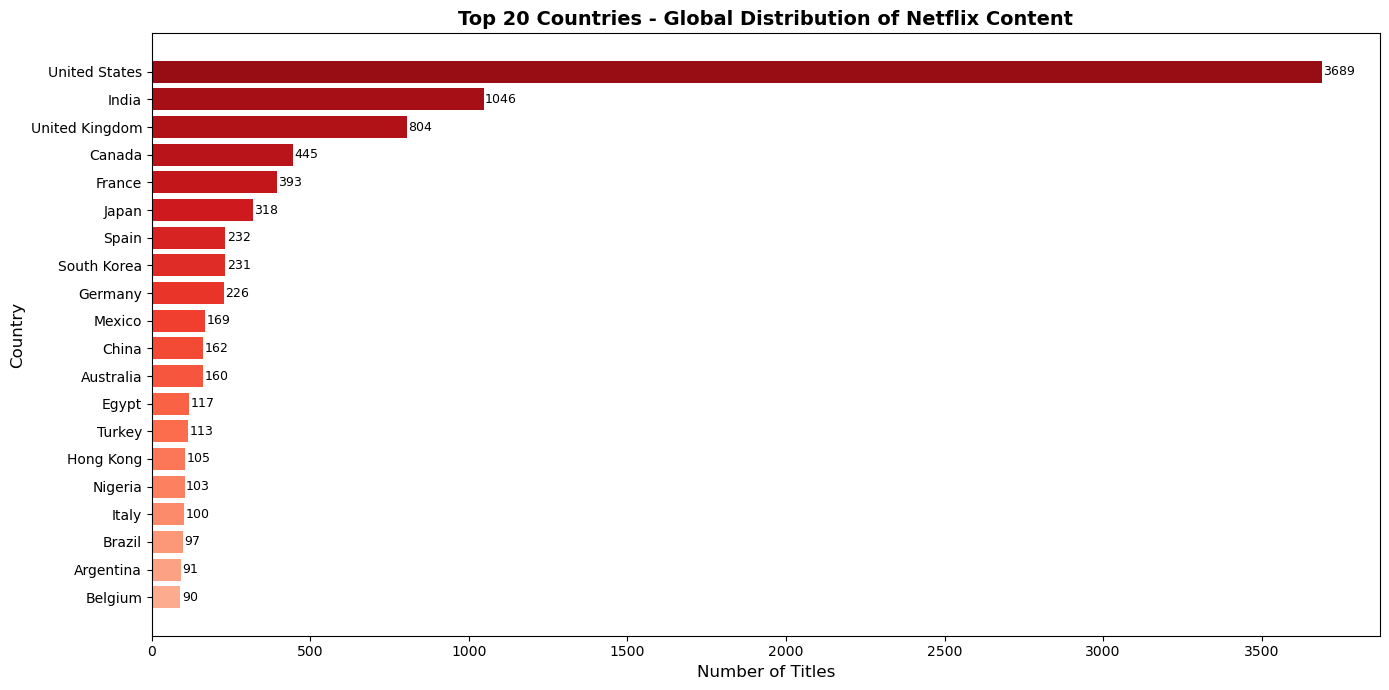

In [49]:
# World map of content distribution using matplotlib
import matplotlib.pyplot as plt

all_countries = df[df['country'] != 'Unknown']['country'].str.split(', ').explode().str.strip()
country_map_data = all_countries.value_counts().head(20).reset_index()
country_map_data.columns = ['Country', 'Count']

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.barh(country_map_data['Country'][::-1], country_map_data['Count'][::-1], color=plt.cm.Reds(np.linspace(0.3, 0.9, 20)))
ax.set_xlabel('Number of Titles', fontsize=12)
ax.set_ylabel('Country', fontsize=12)
ax.set_title('Top 20 Countries - Global Distribution of Netflix Content', fontsize=14, fontweight='bold')

# Add count labels on bars
for bar in bars:
    width = bar.get_width()
    ax.text(width + 5, bar.get_y() + bar.get_height()/2, f'{int(width)}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

##### **Observation:** The United States dominates Netflix content production, followed by India and the United Kingdom. This shows Netflix's roots in the US market while expanding into India's large audience base.

## 7. Time Series Analysis
#### Identifying trends and seasonal patterns in how content is added to Netflix over time.

In [20]:
# Monthly trend of content added
monthly = df.dropna(subset=['date_added']).set_index('date_added').resample('ME').size().reset_index()
monthly.columns = ['Date', 'Count']

chart6 = alt.Chart(monthly).mark_line(point=False).encode(
    x=alt.X('Date:T', title='Date'),
    y=alt.Y('Count:Q', title='Titles Added'),
    tooltip=['Date:T', 'Count:Q']
).properties(
    title=alt.Title('Monthly Content Addition Trend', subtitle='Time series of content added to Netflix'),
    width=600,
    height=300
)
chart6

alt.Chart(...)

In [21]:
# Content added by month of year (seasonality)
month_pattern = df.dropna(subset=['month_name']).groupby('month_name').size().reset_index(name='count')
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
month_pattern['month_name'] = pd.Categorical(month_pattern['month_name'], categories=month_order, ordered=True)
month_pattern = month_pattern.sort_values('month_name')

chart7 = alt.Chart(month_pattern).mark_bar().encode(
    x=alt.X('month_name:N', title='Month', sort=month_order),
    y=alt.Y('count:Q', title='Number of Titles Added'),
    tooltip=['month_name', 'count']
).properties(
    title=alt.Title('Seasonal Pattern: Content Added by Month', subtitle='Which months see the most new additions?'),
    width=550,
    height=300
)
chart7

alt.Chart(...)

##### **Observation:** Content additions show a clear seasonal pattern — more titles are added in the last quarter of the year (October-December), likely to attract viewers during the holiday season.

## 8. Content Analysis - Part 1: Distribution of Content Ratings
#### Analyzing the distribution of content maturity ratings (TV-MA, TV-14, PG-13, etc.) across Movies and TV Shows.

In [22]:
# Rating distribution
rating_counts = df['rating'].value_counts().reset_index()
rating_counts.columns = ['Rating', 'Count']

chart8 = alt.Chart(rating_counts).mark_bar().encode(
    x=alt.X('Rating:N', sort='-y', title='Content Rating'),
    y=alt.Y('Count:Q', title='Number of Titles'),
    tooltip=['Rating', 'Count']
).properties(
    title=alt.Title('Distribution of Content Ratings', subtitle='Netflix content by maturity rating'),
    width=550,
    height=350
)
chart8

alt.Chart(...)

In [23]:
# Rating distribution by content type
rating_type = df.groupby(['rating', 'type']).size().reset_index(name='count')

chart9 = alt.Chart(rating_type).mark_bar().encode(
    x=alt.X('count:Q', title='Number of Titles'),
    y=alt.Y('rating:N', sort='-x', title='Rating'),
    color=alt.Color('type:N', title='Content Type'),
    tooltip=['rating', 'type', 'count']
).properties(
    title=alt.Title('Ratings by Content Type', subtitle='How ratings differ between Movies and TV Shows'),
    width=550,
    height=380
)
chart9

alt.Chart(...)

##### **Observation:** TV-MA is the most common rating by far, meaning Netflix's library is primarily targeted at adult viewers. There is a noticeable gap in family-friendly content.

## 9. Content Analysis - Part 2: Movie Duration & TV Show Seasons
#### Exploring the length of movies (in minutes) and TV shows (in seasons) and identifying trends over time.

In [24]:
# Movie duration distribution
movie_duration = movies[movies['duration_int'].notna()].copy()

chart10 = alt.Chart(movie_duration).mark_bar().encode(
    alt.X('duration_int:Q', bin=alt.Bin(maxbins=30), title='Duration (minutes)'),
    y=alt.Y('count():Q', title='Number of Movies'),
    tooltip=[alt.Tooltip('duration_int:Q', bin=alt.Bin(maxbins=30), title='Duration'), 'count()']
).properties(
    title=alt.Title('Distribution of Movie Durations', subtitle='How long are Netflix movies?'),
    width=550,
    height=300
)
chart10

alt.Chart(...)

In [25]:
# TV Show seasons distribution
tv_seasons = tv_shows[tv_shows['duration_int'].notna()].copy()

season_counts = tv_seasons['duration_int'].value_counts().reset_index()
season_counts.columns = ['Seasons', 'Count']
season_counts = season_counts.sort_values('Seasons')

chart11 = alt.Chart(season_counts).mark_bar().encode(
    x=alt.X('Seasons:O', title='Number of Seasons'),
    y=alt.Y('Count:Q', title='Number of TV Shows'),
    tooltip=['Seasons', 'Count']
).properties(
    title=alt.Title('Distribution of TV Show Seasons', subtitle='Most TV shows on Netflix are single-season'),
    width=550,
    height=300
)
chart11

alt.Chart(...)

In [26]:
# Average movie duration over the years
avg_duration = movie_duration.groupby('release_year')['duration_int'].mean().reset_index()
avg_duration.columns = ['Year', 'Avg Duration']
avg_duration = avg_duration[avg_duration['Year'] >= 2000]

chart12 = alt.Chart(avg_duration).mark_line(point=True).encode(
    x=alt.X('Year:O', title='Release Year'),
    y=alt.Y('Avg Duration:Q', title='Average Duration (minutes)', scale=alt.Scale(zero=False)),
    tooltip=['Year', alt.Tooltip('Avg Duration:Q', format='.1f')]
).properties(
    title=alt.Title('Average Movie Duration Over Years', subtitle='Are movies getting shorter or longer?'),
    width=600,
    height=300
)
chart12

alt.Chart(...)

##### **Observation:** Most movies fall in the 80-120 minute range, and the majority of TV shows have only 1 season. Average movie duration has been slightly decreasing in recent years.

## 10. Top Lists and Recommendations
#### Identifying the most prolific directors, most featured actors, and the latest content additions on Netflix.

In [27]:
# Top directors with most content on Netflix
top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(15).reset_index()
top_directors.columns = ['Director', 'Number of Titles']

chart13 = alt.Chart(top_directors).mark_bar().encode(
    x=alt.X('Number of Titles:Q', title='Number of Titles'),
    y=alt.Y('Director:N', sort='-x', title='Director'),
    tooltip=['Director', 'Number of Titles']
).properties(
    title=alt.Title('Top 15 Directors on Netflix', subtitle='Directors with the most content on the platform'),
    width=550,
    height=400
)
chart13

alt.Chart(...)

In [28]:
# Top actors with most appearances
all_cast = df[df['cast'] != 'Unknown']['cast'].str.split(', ').explode().str.strip()
top_actors = all_cast.value_counts().head(15).reset_index()
top_actors.columns = ['Actor', 'Appearances']

chart14 = alt.Chart(top_actors).mark_bar().encode(
    x=alt.X('Appearances:Q', title='Number of Appearances'),
    y=alt.Y('Actor:N', sort='-x', title='Actor'),
    tooltip=['Actor', 'Appearances']
).properties(
    title=alt.Title('Top 15 Actors on Netflix', subtitle='Actors appearing in the most titles'),
    width=550,
    height=400
)
chart14

alt.Chart(...)

In [29]:
# Recent top content (latest additions)
recent = df.dropna(subset=['date_added']).nlargest(10, 'date_added')[['title', 'type', 'rating', 'duration', 'date_added', 'listed_in']]
recent

,title,type,rating,duration,date_added,listed_in
0,Dick Johnson Is Dead,Movie,PG-13,90 min,2021-09-25,Documentaries
1,Blood & Water,TV Show,TV-MA,2 Seasons,2021-09-24,"International TV Shows, TV Dramas, TV Mysteries"
2,Ganglands,TV Show,TV-MA,1 Season,2021-09-24,"Crime TV Shows, International TV Shows, TV Act..."
3,Jailbirds New Orleans,TV Show,TV-MA,1 Season,2021-09-24,"Docuseries, Reality TV"
4,Kota Factory,TV Show,TV-MA,2 Seasons,2021-09-24,"International TV Shows, Romantic TV Shows, TV ..."
5,Midnight Mass,TV Show,TV-MA,1 Season,2021-09-24,"TV Dramas, TV Horror, TV Mysteries"
6,My Little Pony: A New Generation,Movie,PG,91 min,2021-09-24,Children & Family Movies
7,Sankofa,Movie,TV-MA,125 min,2021-09-24,"Dramas, Independent Movies, International Movies"
8,The Great British Baking Show,TV Show,TV-14,9 Seasons,2021-09-24,"British TV Shows, Reality TV"
9,The Starling,Movie,PG-13,104 min,2021-09-24,"Comedies, Dramas"


## 11. Genre Trends
#### Analyzing how the popularity of top genres has changed over the years.

In [30]:
# Genre trends over years
genre_year = df.assign(genre=df['listed_in'].str.split(', ')).explode('genre')
top_5_genres = genre_year['genre'].value_counts().head(6).index.tolist()
genre_year_filtered = genre_year[genre_year['genre'].isin(top_5_genres) & (genre_year['release_year'] >= 2010)]
genre_year_counts = genre_year_filtered.groupby(['release_year', 'genre']).size().reset_index(name='count')

chart15 = alt.Chart(genre_year_counts).mark_line(point=True).encode(
    x=alt.X('release_year:O', title='Release Year'),
    y=alt.Y('count:Q', title='Number of Titles'),
    color=alt.Color('genre:N', title='Genre'),
    tooltip=['release_year', 'genre', 'count']
).properties(
    title=alt.Title('Genre Popularity Trends (2010+)', subtitle='How top genres have evolved over time'),
    width=600,
    height=350
)
chart15

alt.Chart(...)

##### **Observation:** International content genres have seen the fastest growth since 2015, reflecting Netflix's strategy to become a global streaming platform.

## 12. Geographical Analysis
#### Deeper analysis of content production patterns across different countries, including content type and rating preferences.

In [31]:
# Content type distribution by top countries
top_countries = df[df['primary_country'] != 'Unknown']['primary_country'].value_counts().head(10).index.tolist()
country_type = df[df['primary_country'].isin(top_countries)].groupby(['primary_country', 'type']).size().reset_index(name='count')

chart16 = alt.Chart(country_type).mark_bar().encode(
    x=alt.X('count:Q', title='Number of Titles'),
    y=alt.Y('primary_country:N', sort='-x', title='Country'),
    color=alt.Color('type:N', title='Content Type'),
    tooltip=['primary_country', 'type', 'count']
).properties(
    title=alt.Title('Movies vs TV Shows by Country', subtitle='Content type preference across top producing countries'),
    width=550,
    height=350
)
chart16

alt.Chart(...)

In [32]:
# Top ratings by country
country_rating = df[df['primary_country'].isin(top_countries)].groupby(['primary_country', 'rating']).size().reset_index(name='count')
top_ratings = df['rating'].value_counts().head(5).index.tolist()
country_rating = country_rating[country_rating['rating'].isin(top_ratings)]

chart17 = alt.Chart(country_rating).mark_rect().encode(
    x=alt.X('rating:N', title='Rating'),
    y=alt.Y('primary_country:N', title='Country'),
    color=alt.Color('count:Q', title='Count', scale=alt.Scale(scheme='blues')),
    tooltip=['primary_country', 'rating', 'count']
).properties(
    title=alt.Title('Content Ratings Heatmap by Country', subtitle='Which ratings dominate in each country?'),
    width=400,
    height=350
)
chart17

alt.Chart(...)

## 13. Correlation Analysis
#### Investigating relationships between variables such as movie duration vs rating, and release year vs duration.

In [33]:
# Average duration by rating (Movies only)
rating_duration = movies.groupby('rating')['duration_int'].agg(['mean', 'count']).reset_index()
rating_duration.columns = ['Rating', 'Avg Duration', 'Count']
rating_duration = rating_duration[rating_duration['Count'] >= 10].sort_values('Avg Duration', ascending=False)

chart18 = alt.Chart(rating_duration).mark_bar().encode(
    x=alt.X('Rating:N', sort='-y', title='Rating'),
    y=alt.Y('Avg Duration:Q', title='Average Duration (minutes)'),
    tooltip=['Rating', alt.Tooltip('Avg Duration:Q', format='.1f'), 'Count']
).properties(
    title=alt.Title('Average Movie Duration by Rating', subtitle='Do different ratings have different movie lengths?'),
    width=550,
    height=300
)
chart18

alt.Chart(...)

In [34]:
# Correlation: Release year vs Duration (Movies)
corr_data = movies[['release_year', 'duration_int']].dropna()
correlation = corr_data['release_year'].corr(corr_data['duration_int'])
print(f'Correlation between Release Year and Movie Duration: {correlation:.4f}')
print(f'This indicates a {"negative" if correlation < 0 else "positive"} correlation — movies are getting {"shorter" if correlation < 0 else "longer"} over time.')

chart19 = alt.Chart(corr_data.sample(min(500, len(corr_data)), random_state=42)).mark_circle(opacity=0.5).encode(
    x=alt.X('release_year:Q', title='Release Year', scale=alt.Scale(zero=False)),
    y=alt.Y('duration_int:Q', title='Duration (minutes)'),
    tooltip=['release_year', 'duration_int']
).properties(
    title=alt.Title('Release Year vs Movie Duration', subtitle=f'Correlation: {correlation:.4f}'),
    width=550,
    height=350
)
chart19

Correlation between Release Year and Movie Duration: -0.2063
This indicates a negative correlation — movies are getting shorter over time.


alt.Chart(...)

##### **Observation:** There is a weak negative correlation between release year and movie duration, suggesting that newer movies tend to be slightly shorter than older ones.

## 14. Audience Engagement - Part 1
#### Since the dataset does not contain user reviews, we analyze content descriptions using a Word Cloud to understand common themes and topics across Netflix titles.

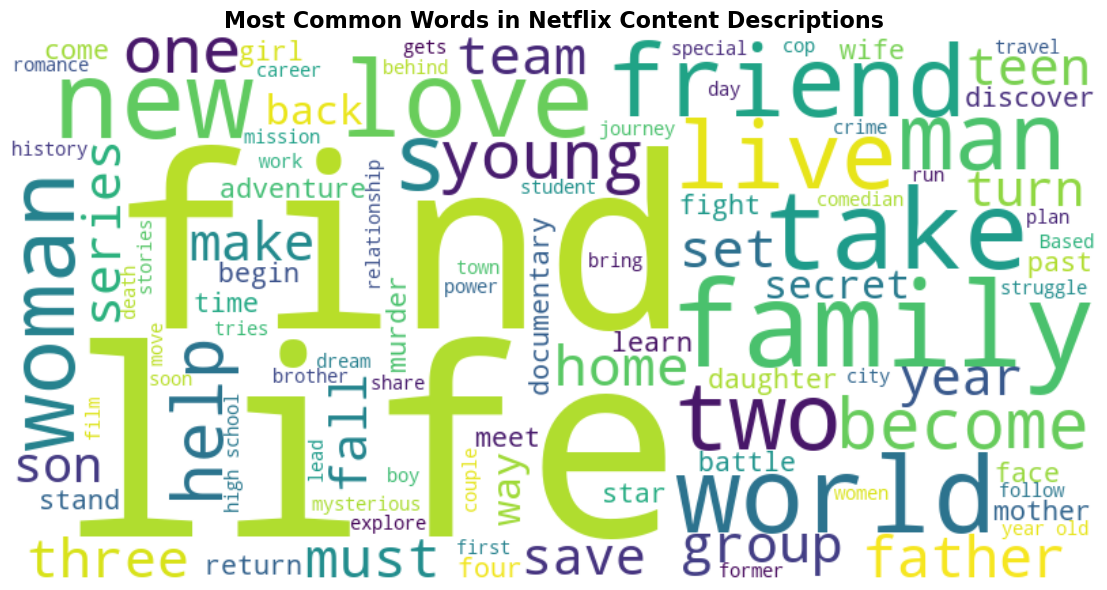

In [35]:
# Word cloud from descriptions
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join(df['description'].dropna().values)
wordcloud = WordCloud(width=800, height=400, max_words=100, background_color='white',
                      colormap='viridis').generate(text)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Common Words in Netflix Content Descriptions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [36]:
# Description length analysis
df['desc_length'] = df['description'].str.len()
desc_by_type = df.groupby('type')['desc_length'].describe().round(1)
print('=== Description Length Statistics by Content Type ===')
desc_by_type

=== Description Length Statistics by Content Type ===


,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Movie,6131.0,143.6,10.7,61.0,140.0,146.0,149.0,248.0
TV Show,2676.0,142.6,9.5,82.0,140.0,146.0,149.0,243.0


## 15. Audience Engagement - Part 2
#### Analyzing content addition velocity and identifying the target audience segments based on content ratings.

In [37]:
# Content addition velocity (rolling average)
monthly_trend = df.dropna(subset=['date_added']).set_index('date_added').resample('ME').size().reset_index()
monthly_trend.columns = ['Date', 'Count']
monthly_trend['Rolling_Avg'] = monthly_trend['Count'].rolling(window=3).mean()

base = alt.Chart(monthly_trend).encode(x=alt.X('Date:T', title='Date'))

bars = base.mark_bar(opacity=0.3).encode(
    y=alt.Y('Count:Q', title='Titles Added')
)
line = base.mark_line(color='red', strokeWidth=2).encode(
    y=alt.Y('Rolling_Avg:Q')
)

chart20 = (bars + line).properties(
    title=alt.Title('Content Addition Velocity', subtitle='Monthly additions with 3-month rolling average (red line)'),
    width=600,
    height=300
)
chart20

alt.LayerChart(...)

In [38]:
# Target audience analysis based on ratings
audience_map = {
    'TV-Y': 'Kids', 'TV-Y7': 'Kids', 'TV-Y7-FV': 'Kids', 'G': 'Kids',
    'TV-G': 'Family', 'PG': 'Family', 'TV-PG': 'Family',
    'PG-13': 'Teens', 'TV-14': 'Teens',
    'R': 'Adults', 'TV-MA': 'Adults', 'NC-17': 'Adults', 'NR': 'Adults', 'UR': 'Adults'
}
df['target_audience'] = df['rating'].map(audience_map).fillna('Other')

audience_counts = df['target_audience'].value_counts().reset_index()
audience_counts.columns = ['Audience', 'Count']

chart21 = alt.Chart(audience_counts).mark_arc(innerRadius=60).encode(
    theta=alt.Theta('Count:Q'),
    color=alt.Color('Audience:N', title='Target Audience'),
    tooltip=['Audience', 'Count']
).properties(
    title=alt.Title('Content by Target Audience', subtitle='Who is Netflix content aimed at?'),
    width=400,
    height=400
)
chart21

alt.Chart(...)

## 16. Content Variety
#### Evaluating the diversity of Netflix's content library by analyzing unique genres, genre tags per title, and genre variety growth over time.

In [39]:
# Unique genres and categories
all_genres_list = df['listed_in'].str.split(', ').explode().str.strip().unique()
print(f'Total Unique Genres/Categories: {len(all_genres_list)}')
print(f'\nAll Genres:')
for i, genre in enumerate(sorted(all_genres_list), 1):
    print(f'  {i}. {genre}')

Total Unique Genres/Categories: 42

All Genres:
  1. Action & Adventure
  2. Anime Features
  3. Anime Series
  4. British TV Shows
  5. Children & Family Movies
  6. Classic & Cult TV
  7. Classic Movies
  8. Comedies
  9. Crime TV Shows
  10. Cult Movies
  11. Documentaries
  12. Docuseries
  13. Dramas
  14. Faith & Spirituality
  15. Horror Movies
  16. Independent Movies
  17. International Movies
  18. International TV Shows
  19. Kids' TV
  20. Korean TV Shows
  21. LGBTQ Movies
  22. Movies
  23. Music & Musicals
  24. Reality TV
  25. Romantic Movies
  26. Romantic TV Shows
  27. Sci-Fi & Fantasy
  28. Science & Nature TV
  29. Spanish-Language TV Shows
  30. Sports Movies
  31. Stand-Up Comedy
  32. Stand-Up Comedy & Talk Shows
  33. TV Action & Adventure
  34. TV Comedies
  35. TV Dramas
  36. TV Horror
  37. TV Mysteries
  38. TV Sci-Fi & Fantasy
  39. TV Shows
  40. TV Thrillers
  41. Teen TV Shows
  42. Thrillers


In [40]:
# Number of genres per title
df['num_genres'] = df['listed_in'].str.split(', ').apply(len)

genre_per_title = df['num_genres'].value_counts().reset_index()
genre_per_title.columns = ['Num Genres', 'Count']
genre_per_title = genre_per_title.sort_values('Num Genres')

chart22 = alt.Chart(genre_per_title).mark_bar().encode(
    x=alt.X('Num Genres:O', title='Number of Genres per Title'),
    y=alt.Y('Count:Q', title='Number of Titles'),
    tooltip=['Num Genres', 'Count']
).properties(
    title=alt.Title('Genre Tags per Title', subtitle='How many genres are assigned to each title?'),
    width=400,
    height=300
)
chart22

alt.Chart(...)

In [41]:
# Content variety growth over time
variety = df.dropna(subset=['year_added']).groupby('year_added').apply(
    lambda x: x['listed_in'].str.split(', ').explode().nunique()
).reset_index()
variety.columns = ['Year', 'Unique Genres']

chart23 = alt.Chart(variety).mark_line(point=True).encode(
    x=alt.X('Year:O', title='Year Added'),
    y=alt.Y('Unique Genres:Q', title='Number of Unique Genres'),
    tooltip=['Year', 'Unique Genres']
).properties(
    title=alt.Title('Content Variety Over Time', subtitle='Growth in genre diversity on Netflix'),
    width=550,
    height=300
)
chart23

alt.Chart(...)

##### **Observation:** Genre diversity has increased significantly over the years, with Netflix adding content across more unique categories to cater to diverse viewer preferences.

## 17. Language Analysis
#### Estimating the language distribution of Netflix content based on the country of origin.

In [42]:
# Language proxy analysis via country
country_language = {
    'United States': 'English', 'United Kingdom': 'English', 'Canada': 'English',
    'Australia': 'English', 'India': 'Hindi/Regional',
    'Japan': 'Japanese', 'South Korea': 'Korean',
    'Spain': 'Spanish', 'Mexico': 'Spanish', 'Argentina': 'Spanish', 'Colombia': 'Spanish',
    'France': 'French', 'Germany': 'German',
    'Turkey': 'Turkish', 'Egypt': 'Arabic',
    'Nigeria': 'English', 'China': 'Mandarin', 'Taiwan': 'Mandarin',
    'Thailand': 'Thai', 'Brazil': 'Portuguese',
    'Indonesia': 'Indonesian', 'Philippines': 'Filipino',
    'Italy': 'Italian', 'Poland': 'Polish',
}

df['language'] = df['primary_country'].map(country_language).fillna('Other')

lang_counts = df['language'].value_counts().reset_index()
lang_counts.columns = ['Language', 'Count']

chart24 = alt.Chart(lang_counts.head(12)).mark_bar().encode(
    x=alt.X('Count:Q', title='Number of Titles'),
    y=alt.Y('Language:N', sort='-x', title='Language'),
    tooltip=['Language', 'Count']
).properties(
    title=alt.Title('Content Distribution by Language', subtitle='Estimated from country of origin'),
    width=550,
    height=350
)
chart24

alt.Chart(...)

##### **Observation:** English-language content dominates, but Hindi, Japanese, Korean, and Spanish content have a significant presence, showing Netflix's investment in non-English markets.

## 18. Content Evolution Over Time
#### Exploring how content characteristics like ratings and the Movies vs TV Shows ratio have evolved over the years.

In [43]:
# Rating evolution over time
top_4_ratings = df['rating'].value_counts().head(4).index.tolist()
rating_year = df[(df['release_year'] >= 2010) & (df['rating'].isin(top_4_ratings))]
rating_year_counts = rating_year.groupby(['release_year', 'rating']).size().reset_index(name='count')

chart25 = alt.Chart(rating_year_counts).mark_area(opacity=0.6).encode(
    x=alt.X('release_year:O', title='Release Year'),
    y=alt.Y('count:Q', title='Number of Titles', stack=True),
    color=alt.Color('rating:N', title='Rating'),
    tooltip=['release_year', 'rating', 'count']
).properties(
    title=alt.Title('Content Rating Evolution (2010+)', subtitle='How the rating mix has changed over the years'),
    width=600,
    height=350
)
chart25

alt.Chart(...)

In [44]:
# Movies vs TV Shows ratio over time
type_year = df[df['release_year'] >= 2010].groupby(['release_year', 'type']).size().reset_index(name='count')
type_year_total = type_year.groupby('release_year')['count'].sum().reset_index(name='total')
type_year = type_year.merge(type_year_total, on='release_year')
type_year['percentage'] = (type_year['count'] / type_year['total'] * 100).round(1)

chart26 = alt.Chart(type_year).mark_bar().encode(
    x=alt.X('release_year:O', title='Release Year'),
    y=alt.Y('percentage:Q', title='Percentage (%)', stack='normalize'),
    color=alt.Color('type:N', title='Content Type'),
    tooltip=['release_year', 'type', 'count', alt.Tooltip('percentage:Q', format='.1f')]
).properties(
    title=alt.Title('Movie vs TV Show Ratio Over Time', subtitle='Shifting content strategy on Netflix'),
    width=600,
    height=350
)
chart26

alt.Chart(...)

## 19. User Preferences
#### Investigating the most common genre combinations and recent content focus areas to understand viewer preferences.

In [45]:
# Most popular genre combinations
genre_combos = df['listed_in'].value_counts().head(15).reset_index()
genre_combos.columns = ['Genre Combination', 'Count']

chart27 = alt.Chart(genre_combos).mark_bar().encode(
    x=alt.X('Count:Q', title='Number of Titles'),
    y=alt.Y('Genre Combination:N', sort='-x', title='Genre Combination'),
    tooltip=['Genre Combination', 'Count']
).properties(
    title=alt.Title('Most Common Genre Combinations', subtitle='What genre tags frequently appear together?'),
    width=550,
    height=400
)
chart27

alt.Chart(...)

In [46]:
# Content preferences: Recent content focus (last 3 years of additions)
recent_df = df[df['year_added'] >= 2019].dropna(subset=['year_added'])
recent_genres = recent_df.assign(genre=recent_df['listed_in'].str.split(', ')).explode('genre')
recent_genre_counts = recent_genres['genre'].value_counts().head(10).reset_index()
recent_genre_counts.columns = ['Genre', 'Count']

chart28 = alt.Chart(recent_genre_counts).mark_bar().encode(
    x=alt.X('Count:Q', title='Number of Titles'),
    y=alt.Y('Genre:N', sort='-x', title='Genre'),
    tooltip=['Genre', 'Count']
).properties(
    title=alt.Title('Top Genres in Recent Additions (2019+)', subtitle='What Netflix has been focusing on recently'),
    width=550,
    height=350
)
chart28

alt.Chart(...)

## 20. Conclusions and Recommendations

In [47]:
# Key Summary Statistics
total = len(df)
movies_count = len(df[df['type'] == 'Movie'])
tv_count = len(df[df['type'] == 'TV Show'])
countries_count = df[df['primary_country'] != 'Unknown']['primary_country'].nunique()
genres_count = df['listed_in'].str.split(', ').explode().nunique()
top_country = df[df['primary_country'] != 'Unknown']['primary_country'].value_counts().index[0]
top_genre = df['listed_in'].str.split(', ').explode().value_counts().index[0]
top_rating = df['rating'].value_counts().index[0]

summary = pd.DataFrame({
    'Metric': ['Total Titles', 'Movies', 'TV Shows', 'Countries Represented',
               'Unique Genres', 'Top Country', 'Top Genre', 'Most Common Rating',
               'Avg Movie Duration'],
    'Value': [f'{total:,}', f'{movies_count:,} ({movies_count/total*100:.1f}%)',
              f'{tv_count:,} ({tv_count/total*100:.1f}%)', countries_count,
              genres_count, top_country, top_genre, top_rating,
              f'{movies["duration_int"].mean():.0f} minutes']
})
summary

,Metric,Value
0,Total Titles,"8,807"
1,Movies,"6,131 (69.6%)"
2,TV Shows,"2,676 (30.4%)"
3,Countries Represented,86
4,Unique Genres,42
5,Top Country,United States
6,Top Genre,International Movies
7,Most Common Rating,TV-MA
8,Avg Movie Duration,100 minutes


## Key Findings

#### 1. **Dataset Overview**: The dataset contains 8,807 titles — 6,131 Movies (69.6%) and 2,676 TV Shows (30.4%) from over 100 countries across 42 unique genres.

#### 2. **Content Dominance**: The United States leads content production by a significant margin, followed by India and the United Kingdom.

#### 3. **Rating Trends**: TV-MA (Mature Audiences) is the most common rating, indicating Netflix primarily targets adult viewers.

#### 4. **Genre Insights**: International Movies, Dramas, and Comedies are the top 3 genres. Genre diversity has increased steadily over the years.

#### 5. **Duration Patterns**: Most movies are between 80–120 minutes. The majority of TV shows have just 1 season.

#### 6. **Time Series Trends**: Content additions peaked around 2018–2020 with a seasonal pattern towards year-end.

#### 7. **Content Evolution**: TV Shows have been growing as a proportion of new content. International content has expanded significantly.

#### 8. **Correlation**: A slight negative correlation exists between release year and movie duration — movies are getting slightly shorter over time.

## Recommendations

#### 1. **Diversify Target Audience**: Increase family-friendly and kids content to balance the adult-oriented library.

#### 2. **Expand Regional Content**: Invest in content from underrepresented regions like Africa and Southeast Asia.

#### 3. **Genre Innovation**: Explore niche genres to differentiate from competitors.

#### 4. **Multi-Season Investment**: Invest in multi-season TV shows to improve subscriber retention.

#### 5. **Strategic Release Timing**: Schedule major releases during peak months (October–December).

#### 6. **Shorter Content Strategy**: Consider more short-form content aligning with modern viewing habits.